In [35]:
import webbpsf
import numpy as np
import matplotlib.pyplot as plt

In [36]:
wfi = webbpsf.WFI()
wfi.filter = "GRISM0"

In [37]:
fov_pixels = 364
wavelength = 1.5e-6
oversample = 4

In [38]:
grid = wfi.psf_grid(all_detectors=False, use_detsampled_psf=False, monochromatic=wavelength, fov_pixels=fov_pixels, oversample=oversample)

Attempted to get aberrations at field point (0, 0) which is outside the range of the reference data; approximating to nearest interpolated point (10.879642720575857, 0.0026943146905864523)



Running instrument: WFI, filter: GRISM0
  Running detector: SCA01
    Position 1/16: (0, 0) pixels


Attempted to get aberrations at field point (0, 1365) which is outside the range of the reference data; approximating to nearest interpolated point (10.54160410832087, 1365.002610600324)


    Position 1/16 centroid: (727.2580716041166, 727.9126853570226)
    Position 2/16: (0, 1365) pixels


Attempted to get aberrations at field point (0, 2730) which is outside the range of the reference data; approximating to nearest interpolated point (10.203565496065885, 2730.002526885957)


...

    Position 13/16 centroid: (727.3078602545243, 728.0329110057739)
    Position 14/16: (4095, 1365) pixels


Attempted to get aberrations at field point (4095, 2730) which is outside the range of the reference data; approximating to nearest interpolated point (4039.405164703233, 2729.9724641727107)


    Position 14/16 centroid: (727.3197908979319, 728.0507814886885)
    Position 15/16: (4095, 2730) pixels


Attempted to get aberrations at field point (4095, 4095) which is outside the range of the reference data; approximating to nearest input grid point


    Position 15/16 centroid: (727.3316222417346, 728.0680892213992)
    Position 16/16: (4095, 4095) pixels
    Position 16/16 centroid: (727.3387059159353, 728.078250336361)


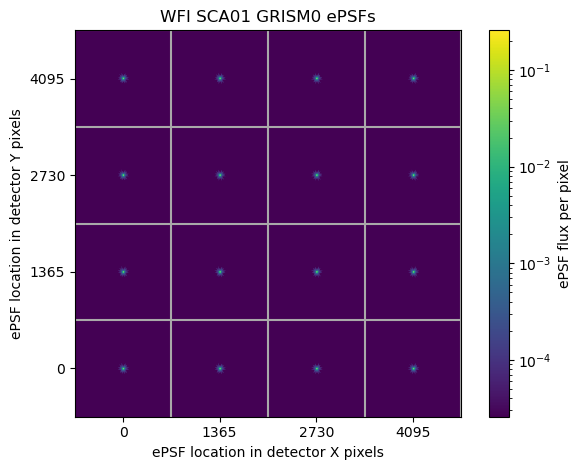

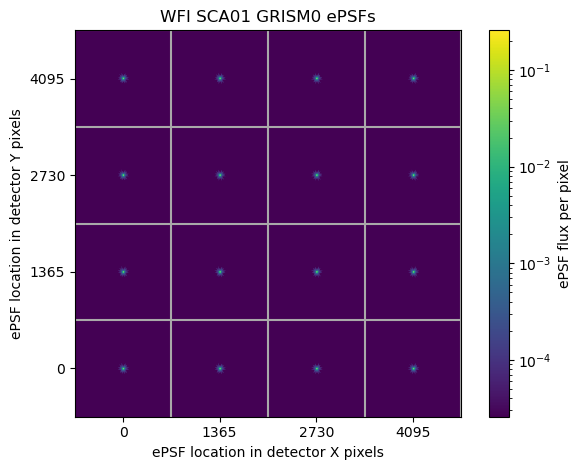

In [39]:
grid.plot_grid()

In [40]:
x0 = 0
y0 = 0
half_fov = int(fov_pixels / 2) * oversample

y, x = np.mgrid[y0-half_fov:y0+half_fov, x0-half_fov:x0+half_fov]
center = grid.evaluate(x=x, y=y, flux=1, x_0=x0, y_0=y0)

y, x = np.mgrid[y0-half_fov+5:y0+half_fov+5, x0-half_fov+5:x0+half_fov+5]
off_center = grid.evaluate(x=x, y=y, flux=1, x_0=x0+5, y_0=y0+5)

y, x = np.mgrid[y0-half_fov+10:y0+half_fov+10, x0-half_fov+10:x0+half_fov+10]
double_off = grid.evaluate(x=x, y=y, flux=1, x_0=x0+10, y_0=y0+10)

Text(0.5, 1.0, 'off_center - double_off')

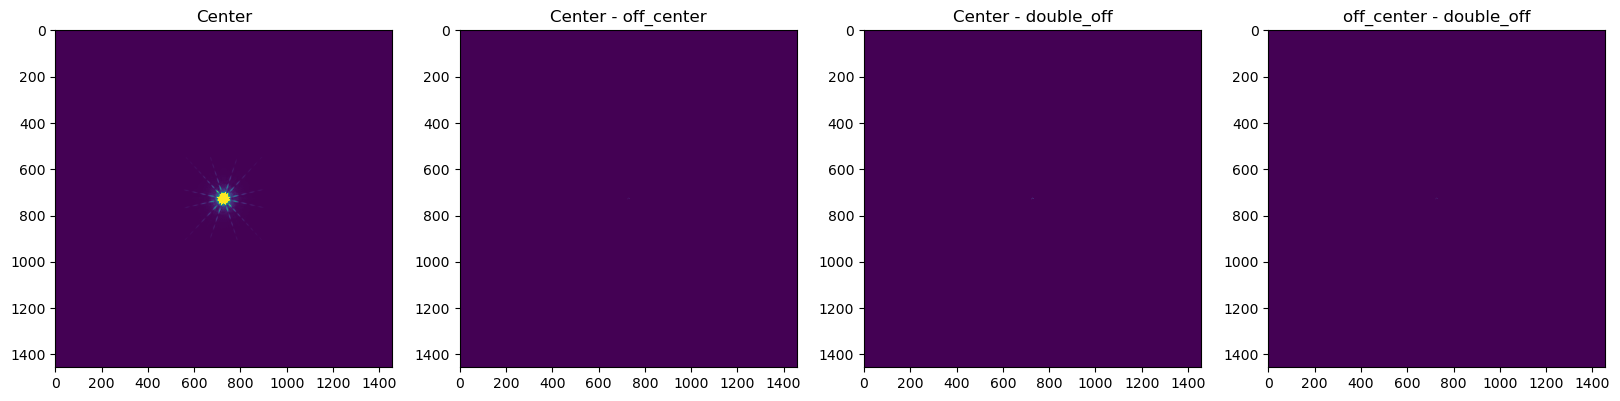

In [41]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)

fig.set_size_inches(20, 20)

ax1.imshow(center, vmin=0, vmax=1e-5)
ax1.set_title("Center")

ax2.imshow(center - off_center, vmin=0, vmax=1e-5)
ax2.set_title("Center - off_center")

ax3.imshow(center - double_off, vmin=0, vmax=1e-5)
ax3.set_title("Center - double_off")

ax4.imshow(off_center - double_off, vmin=0, vmax=1e-5)
ax4.set_title("off_center - double_off")

In [42]:
wfi.detector_position = (x0, y0)
psf = wfi.calc_psf(monochromatic=wavelength, fov_pixels=fov_pixels, oversample=oversample)

Attempted to get aberrations at field point (0, 0) which is outside the range of the reference data; approximating to nearest interpolated point (10.879642720575857, 0.0026943146905864523)


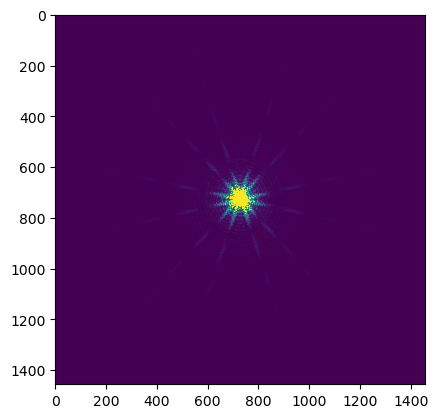

In [43]:
plt.imshow(psf[0].data, vmin=0, vmax=1e-5)

In [44]:
np.any(center - psf[0].data)

True

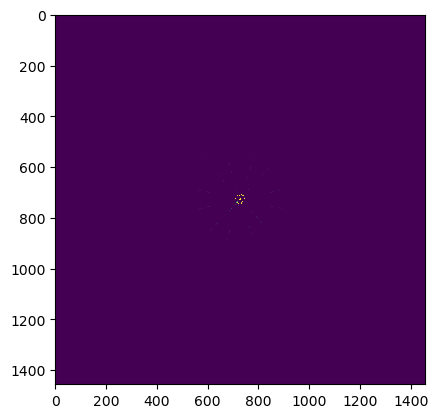

In [45]:
plt.imshow(center - psf[0].data, vmin=0, vmax=1e-5)

In [46]:
center.max()

0.25921111684226755

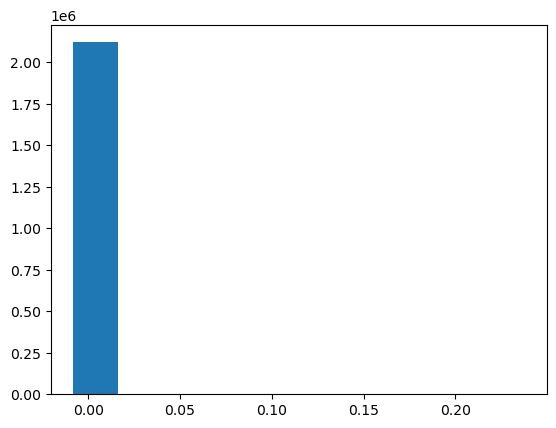

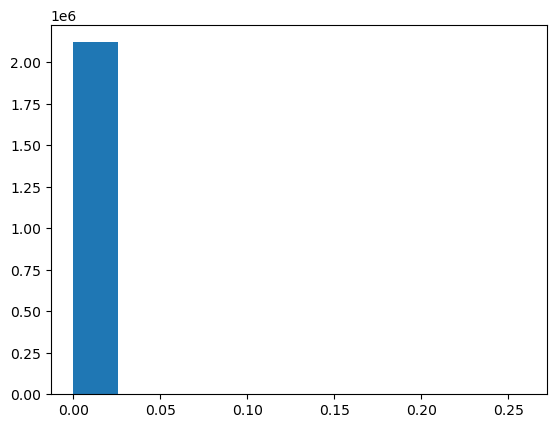

(array([2.119874e+06, 2.600000e+01, 4.000000e+00, 8.000000e+00,
        8.000000e+00, 1.000000e+00, 3.000000e+00, 8.000000e+00,
        0.000000e+00, 4.000000e+00]),
 array([2.35208422e-12, 2.16823333e-03, 4.33646666e-03, 6.50469999e-03,
        8.67293332e-03, 1.08411666e-02, 1.30094000e-02, 1.51776333e-02,
        1.73458666e-02, 1.95141000e-02, 2.16823333e-02]),
 <BarContainer object of 10 artists>)

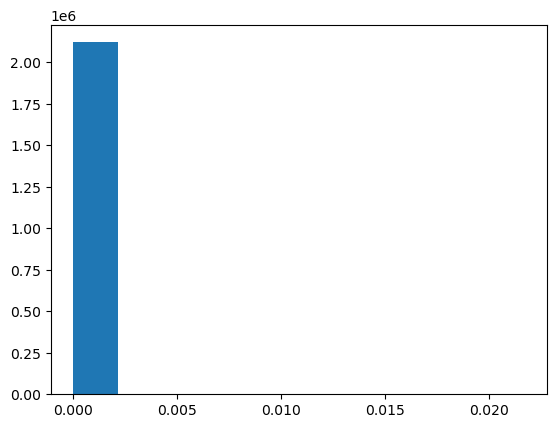

In [47]:
plt.hist((center - psf[0].data).flatten())
plt.show()
plt.hist(center.flatten())
plt.show()
plt.hist(psf[0].data.flatten())

In [48]:
raise Exception()

Exception: 

In [ ]:
grid = roman.psf_grid(all_detectors=True, save=True, use_detsampled_psf=True,
                      monochromatic=10000*10**-10, outdir="/Users/keith/astr/research_astr/mkstar_psf_test/psf_grids", outfile=f"grid_at_{start_wave}")

In [ ]:
from webbpsf.utils import to_griddedpsfmodel
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
grid = to_griddedpsfmodel("/Users/keith/astr/research_astr/mkstar_psf_test/psf_grids/grid_at_10000_sca01.fits")

In [ ]:
grid

In [ ]:
y, x = np.mgrid[2000:2100, 2000:2100]

center = grid.evaluate(x=x, y=y, flux=1, x_0=x[50][50], y_0=y[50][50])

y, x = np.mgrid[2005:2105, 2005:2105]
off_center = grid.evaluate(x=x, y=y, flux=1, x_0=x[50][50], y_0=y[50][50])

y, x = np.mgrid[2010:2110, 2010:2110]
double_off = grid.evaluate(x=x, y=y, flux=1, x_0=x[50][50], y_0=y[50][50])

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)

fig.set_size_inches(20, 20)

ax1.imshow(center, vmin=0, vmax=1e-5)
ax1.set_title("Center")

ax2.imshow(center - off_center, vmin=0, vmax=1e-5)
ax2.set_title("Center - off_center")

ax3.imshow(center - double_off, vmin=0, vmax=1e-5)
ax3.set_title("Center - double_off")

ax4.imshow(off_center - double_off, vmin=0, vmax=1e-5)
ax4.set_title("off_center - double_off")